# 💰 Sesión 9 — De la prima pura a la prima de tarifa: ajuste por inflación
## Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro · UNAM

---

**Semana 4 · Tema 2 (Cálculo de primas)** · **Herramienta:** Python

---

> **Objetivo:** ya tienen la prima pura de su ramo (Tema 1). Aquí ven el **primer ajuste** para
> llegar al precio: llevar los montos históricos a **valor de hoy** (inflación), medir cómo eso
> **mueve la prima pura**, y asomarse a la **devaluación**. Y sobre todo: **documentar cada supuesto**,
> porque así se construye una nota técnica.
>
> 🟢 Las celdas normales las corremos juntos. **✏️ Las de Ejercicio las completas tú.**

## Contenido
1. [Entorno](#1)
2. [El problema: montos de años distintos](#2)
3. [Ajuste por inflación con un índice](#3)
4. [Efecto en la severidad y en la prima pura](#4)
5. [Un vistazo a la devaluación](#5)
6. [Documentar los supuestos (nota técnica)](#6)
7. [Cierre](#7)

---

---
<a id='1'></a>
## 1. Entorno

In [1]:
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
np.random.seed(9); plt.rcParams["figure.figsize"] = (8, 3.6)
print("✓ listo")

✓ listo


---
<a id='2'></a>
## 2. El problema: montos de años distintos

Una cartera real tiene siniestros de **varios años**, cada uno en **pesos de su año**. Si los mezclas
tal cual, los años viejos "valen menos" y **subestimas** el costo actual. Simulamos una tabla de
siniestros con su año de ocurrencia.

In [15]:
# ─── Siniestros históricos (año de ocurrencia + monto nominal) ─────────────
anios = np.arange(2019, 2025)
n_por_anio = 400
# la severidad "real" crece con la inflación; aquí la generamos en pesos de cada año
infl_real = {2019:1.00, 2020:1.034, 2021:1.108, 2022:1.196, 2023:1.260, 2024:1.316} ## Señala la inflacion por año 
filas = []
for a in anios:
    montos = np.random.lognormal(mean=np.log(40000*infl_real[a]), sigma=0.9, size=n_por_anio)
    filas.append(pd.DataFrame({"anio": a, "monto_nominal": montos.round(0)}))
sin = pd.concat(filas, ignore_index=True)

print(sin.groupby("anio")["monto_nominal"].mean().round(0).to_string())
print(f"\nSeveridad media SIN ajustar (todos los años juntos): {sin.monto_nominal.mean():,.0f}")
print("→ mezcla pesos de 2019 con pesos de 2024: no es comparable.")
print(f"nos dice que en promedio de los siniestros son de 65-70 mil, lo cual es logico, pero no es comparable entre años, \n"
       f"ya que la inflación hace que el valor del dinero cambie con el tiempo, no es lo mismo un siniestro de ese monto en \n"
       f"2019 que en 2024, por lo que es necesario ajustar los montos a un mismo año para poder compararlos.")

anio
2019    58107.0
2020    64068.0
2021    60920.0
2022    69165.0
2023    74168.0
2024    78780.0

Severidad media SIN ajustar (todos los años juntos): 67,535
→ mezcla pesos de 2019 con pesos de 2024: no es comparable.
nos dice que en promedio de los siniestros son de 65-70 mil, lo cual es logico, pero no es comparable entre años, 
ya que la inflación hace que el valor del dinero cambie con el tiempo, no es lo mismo un siniestro de ese monto en 
2019 que en 2024, por lo que es necesario ajustar los montos a un mismo año para poder compararlos.


---
<a id='3'></a>
## 3. Ajuste por inflación con un índice

Cada monto se lleva a **valor de hoy** multiplicándolo por el cociente de índices:

$$X^{\mathrm{ajust}}_t = X_t \times \frac{I_{\mathrm{hoy}}}{I_t}$$

Usamos un índice acumulado (aquí ilustrativo; en la práctica sería el INPC o uno propio del ramo).

      nominal  ajustado
anio                   
2019  58107.0   76469.0
2020  64068.0   81542.0
2021  60920.0   72356.0
2022  69165.0   76105.0
2023  74168.0   77464.0
2024  78780.0   78780.0


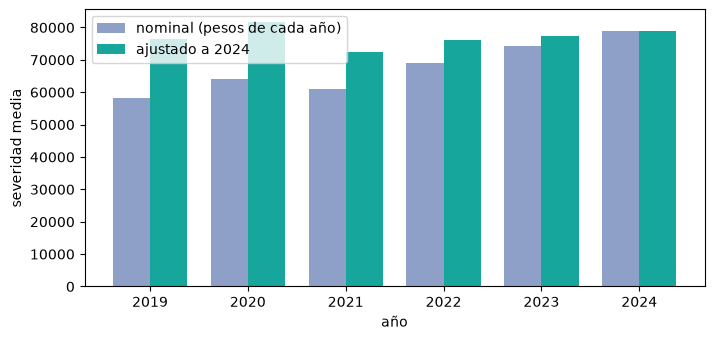

Tras ajustar, los años viejos suben a valor de hoy y se vuelven comparables.


In [16]:
# ─── Llevar todo a valor de 2024 ───────────────────────────────────────────
indice = {2019:1.00, 2020:1.034, 2021:1.108, 2022:1.196, 2023:1.260, 2024:1.316}
I_hoy = indice[2024]
sin["factor"] = sin["anio"].map(lambda a: I_hoy / indice[a])
sin["monto_ajustado"] = (sin["monto_nominal"] * sin["factor"]).round(0)

comp = sin.groupby("anio").agg(nominal=("monto_nominal","mean"),
                               ajustado=("monto_ajustado","mean")).round(0)
print(comp.to_string())
w=0.38
plt.bar(anios-w/2, comp["nominal"], width=w, label="nominal (pesos de cada año)", color="#8FA0C8")
plt.bar(anios+w/2, comp["ajustado"], width=w, label="ajustado a 2024", color="#17A69B")
plt.xlabel("año"); plt.ylabel("severidad media"); plt.legend(); plt.show()
print("Tras ajustar, los años viejos suben a valor de hoy y se vuelven comparables.")


### ✏️ Ejercicio 1 — el factor de un año

1. ¿Cuál es el factor de ajuste de **2020** a valor de 2024?
2. Un siniestro de 2020 por \$30,000 nominales, ¿cuánto vale en pesos de 2024?

In [17]:
# Ejercicio 1
factor_2020 = I_hoy / indice[2020]
print(f"Factor de ajuste de 2020: {factor_2020:.4f}")

sinistro_2020_nominal = 30000 
sinistro_2020_ajustado = sinistro_2020_nominal * factor_2020
print(f"Siniestro de 2020: ${sinistro_2020_nominal:,} nominales → ${sinistro_2020_ajustado:,.2f} en pesos de 2024")


Factor de ajuste de 2020: 1.2727
Siniestro de 2020: $30,000 nominales → $38,181.82 en pesos de 2024


---
<a id='4'></a>
## 4. Efecto en la severidad y en la prima pura

La prima pura es frecuencia × severidad. La frecuencia no cambia con la inflación, pero **la severidad
sí**: comparamos la prima pura con y sin ajuste.

In [ ]:
# ─── Prima pura: sin ajustar vs. ajustada ──────────────────────────────────
frecuencia = 0.30                                   # siniestros por año-póliza (dato del Tema 1)
EX_sin = sin.monto_nominal.mean()
EX_aj  = sin.monto_ajustado.mean()
pp_sin = frecuencia * EX_sin
pp_aj  = frecuencia * EX_aj

print(f"Severidad media  sin ajustar : {EX_sin:,.0f}")
print(f"Severidad media  ajustada    : {EX_aj:,.0f}")
print(f"\nPrima pura sin ajustar : {pp_sin:,.0f} por año-póliza")
print(f"Prima pura ajustada    : {pp_aj:,.0f} por año-póliza")
print(f"\nSubestimación si NO ajustas: {1 - pp_sin/pp_aj:.1%}")
print("Ignorar la inflación deja la prima corta — y con ella, insuficiencia de reservas.")

Severidad media  sin ajustar : 68,966
Severidad media  ajustada    : 78,983

Prima pura sin ajustar : 20,690 por año-póliza
Prima pura ajustada    : 23,695 por año-póliza

Subestimación si NO ajustas: 12.7%
Ignorar la inflación deja la prima corta — y con ella, insuficiencia de reservas.


### ✏️ Ejercicio 2 — el costo de no ajustar

1. Recalcula la prima pura ajustada suponiendo una **frecuencia de 0.45** en vez de 0.30.
2. ¿La *subestimación relativa* (%) por no ajustar cambia con la frecuencia? ¿Por qué?

In [ ]:
# Tu código aquí 👇
frecuencia2 = 0.45

#prima pura sin severidad ajustada
pp_sin_2 = frecuencia2 * EX_sin

#prima pura con severidad ajustada
pp_aj_2  = frecuencia2 * EX_aj

#Calculo de la subestimación
subestimacion_2 = 1 - pp_sin_2/pp_aj_2

print(f"Prima pura sin ajustar la severidad (frec 0.45): {pp_sin_2:,.0f}")
print(f"Prima pura con severidad ajustada (frec 0.45):    {pp_aj_2:,.0f}")
print(f"Subestimación relativa: {subestimacion_2:.1%}")
print("la subestimación relativa no cambia con la frecuencia, porque 1 - pp_sin/pp_aj = 1 - EX_sin/EX_aj ")
print("la frecuencia se cancela al dividir Podemos darnos cuenta que da lo mismo que con 0.30.")

Prima pura sin ajustar la severidad (frec 0.45): 30,391
Prima pura con severidad ajustada (frec 0.45):    34,704
Subestimación relativa: 12.4%
la subestimación relativa no cambia con la frecuencia, porque 1 - pp_sin/pp_aj = 1 - EX_sin/EX_aj 
la frecuencia se cancela al dividir Podemos darnos cuenta que da lo mismo que con 0.30.


---
<a id='5'></a>
## 5. Un vistazo a la devaluación

En ramos con exposición en **dólares** (marítimo, transportes), la suma asegurada y el siniestro se
convierten a pesos con el tipo de cambio:

$$SA_{\mathrm{MXN}} = SA_{\mathrm{USD}} \times TC$$

Una devaluación (TC más alto) **encarece** el costo en pesos.

In [7]:
# ─── Efecto del tipo de cambio en una cartera en USD ───────────────────────
sa_usd = 100_000                    # suma asegurada en dólares
for tc in [17.0, 18.5, 20.0]:
    print(f"TC = {tc:>5.1f}  →  suma asegurada en pesos = {sa_usd*tc:,.0f}")
print("\nEl mismo bien 'cuesta' más pesos si el peso se devalúa: la prima en pesos debe reflejarlo.")

TC =  17.0  →  suma asegurada en pesos = 1,700,000
TC =  18.5  →  suma asegurada en pesos = 1,850,000
TC =  20.0  →  suma asegurada en pesos = 2,000,000

El mismo bien 'cuesta' más pesos si el peso se devalúa: la prima en pesos debe reflejarlo.


### ✏️ Ejercicio 3 — sensibilidad al tipo de cambio

1. Con `sa_usd = 250,000`, calcula la suma asegurada en pesos para TC = 17 y TC = 21.
2. ¿En qué porcentaje sube el costo en pesos al pasar de 17 a 21?

In [28]:
# Tu código aquí 👇
#SA en dolares
sa_usd = 250_000

# SA con tasa de cambio 17 MXN
sa_17 = sa_usd * 17

# SA con tasa de cambio 21 MXN
sa_21 = sa_usd * 21

# porcentaje de subida de costo entre TC=17, TC=21,
pct_subida = (sa_21 - sa_17) / sa_17
print(f"El costo en pesos sube {pct_subida:.1%} al pasar el TC de 17 a 21")


El costo en pesos sube 23.5% al pasar el TC de 17 a 21


---
<a id='6'></a>
## 6. Documentar los supuestos (nota técnica)

Cada ajuste que hicimos es un **supuesto** que la nota técnica debe justificar. Dejamos el registro
explícito — esto es parte de la entrega, no un adorno.

In [9]:
# ─── Registro de supuestos (así se documenta) ──────────────────────────────
supuestos = pd.DataFrame([
    {"supuesto": "Índice de inflación", "valor": "acumulado 2019–2024 (ilustrativo; usar INPC)", "fuente": "INEGI / propio del ramo"},
    {"supuesto": "Año base de ajuste",  "valor": "2024 (valor de hoy)",                         "fuente": "criterio del actuario"},
    {"supuesto": "Frecuencia",          "valor": f"{frecuencia:.2f} sin/año-póliza",             "fuente": "Tema 1 (ajuste propio)"},
    {"supuesto": "Tipo de cambio",      "valor": "escenario 17–20 MXN/USD",                     "fuente": "Banxico"},
])
print(supuestos.to_string(index=False))
print("\nRegla: un número sin fuente y sin justificación NO es válido ante la CNSF.")

           supuesto                                        valor                  fuente
Índice de inflación acumulado 2019–2024 (ilustrativo; usar INPC) INEGI / propio del ramo
 Año base de ajuste                          2024 (valor de hoy)   criterio del actuario
         Frecuencia                          0.30 sin/año-póliza  Tema 1 (ajuste propio)
     Tipo de cambio                      escenario 17–20 MXN/USD                 Banxico

Regla: un número sin fuente y sin justificación NO es válido ante la CNSF.


### ✏️ Ejercicio 4 — tu tabla de supuestos

Para tu ramo, agrega **una fila** a la tabla de supuestos con un ajuste que aplique a tu cartera
(por ejemplo, depreciación si aseguras bienes, o el índice que usarías), con su **valor** y su
**fuente**.

In [10]:
# Tu código aquí 👇


---
<a id='7'></a>
## 7. Cierre

- La **inflación** lleva los montos históricos a valor de hoy; sin ese ajuste, la prima pura queda **corta**.
- La **devaluación** y la **depreciación** ajustan el valor del bien y del siniestro en el tiempo.
- Todo esto es **prima pura ajustada**, todavía **NO el precio**: faltan gastos, margen, IBNR y reaseguro.
- Cada ajuste es un **supuesto documentado y validado**: así se construye la nota técnica.

**Próxima sesión:** los recargos — gastos, comisiones, márgenes técnicos y la prima comercial.

---
*Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro · Semana 4 · Sesión 9*